This notebook will:


*  Model asset dynamics with Geometric Brownian Motion
*  Verify the Martingale Property
*  Price options using Black–Scholes
*  Extend to Merton Jump Diffusion
*  Simulate paths with Monte Carlo
*  Model volatility with GARCH
*  Build a trading strategy
*  Backtest with realistic assumptions























---



Install required packages


In [74]:
!pip install yfinance arch statsmodels --quiet
!pip install quantstats

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
import quantstats as qs

from scipy.stats import norm
from arch import arch_model
from statsmodels.tsa.arima.model import ARIMA

Collecting the data, inculding chech of skewness and kurtosis of returns

/tmp/ipykernel_703/1928083504.py:3: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(ticker, start="2010-01-01")
[*********************100%***********************]  1 of 1 completed


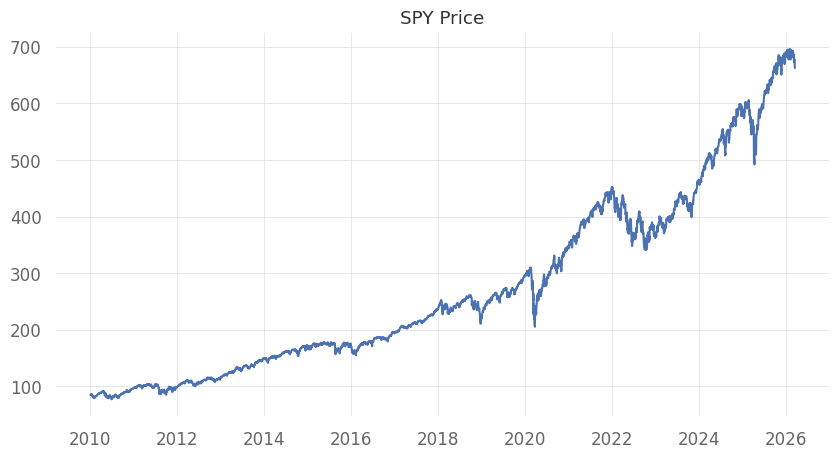

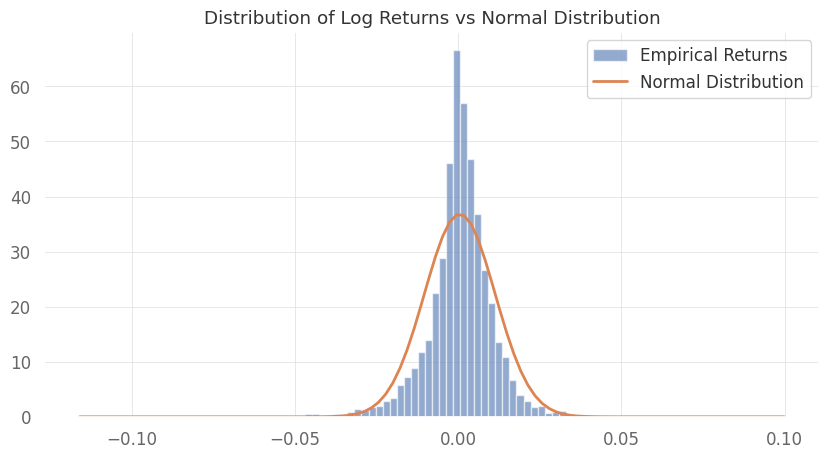

Skew: -0.5611916497211556
Kurtosis: 12.477856176909492


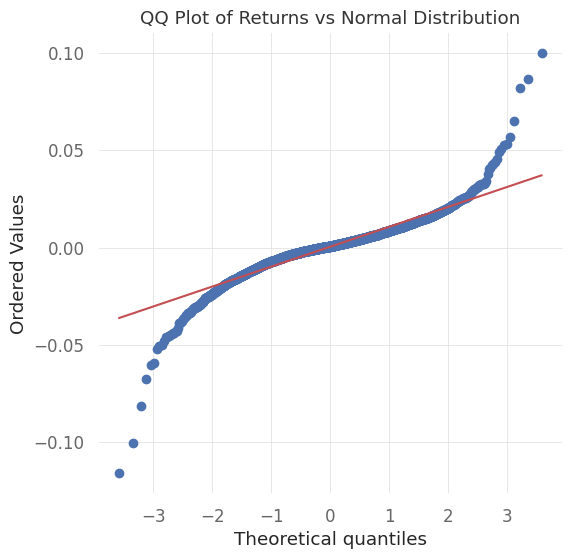

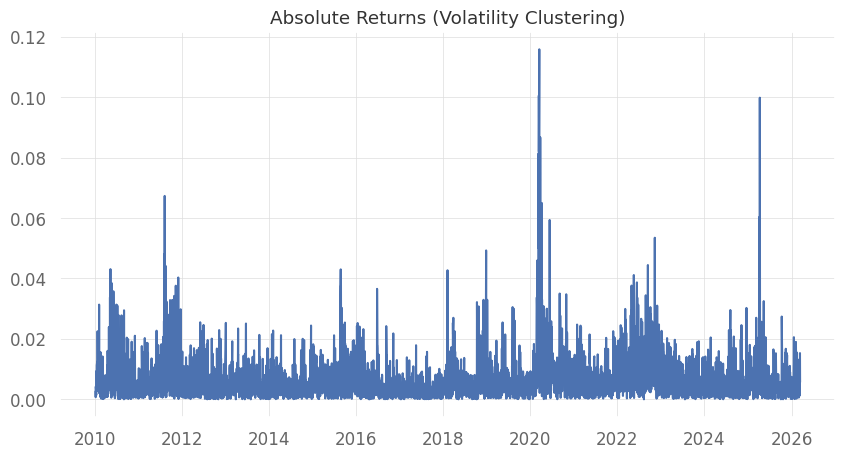

In [75]:
ticker = "SPY"

data = yf.download(ticker, start="2010-01-01")

data["log_returns"] = np.log(data["Close"] / data["Close"].shift(1))

data = data.dropna()

plt.figure(figsize=(10,5))
plt.plot(data["Close"])
plt.title("SPY Price")
plt.show()

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import kurtosis, skew, norm

returns = data["log_returns"]

mu = returns.mean()
sigma = returns.std()

x = np.linspace(returns.min(), returns.max(), 100)

plt.figure(figsize=(10,5))

plt.hist(returns, bins=100, density=True, alpha=0.6, label="Empirical Returns")
plt.plot(x, norm.pdf(x, mu, sigma), linewidth=2, label="Normal Distribution")

plt.title("Distribution of Log Returns vs Normal Distribution")
plt.legend()

plt.show()

print("Skew:", skew(returns))
print("Kurtosis:", kurtosis(returns))


import scipy.stats as stats

plt.figure(figsize=(6,6))

stats.probplot(returns, dist="norm", plot=plt)

plt.title("QQ Plot of Returns vs Normal Distribution")

plt.show()

plt.figure(figsize=(10,5))

plt.plot(np.abs(returns))

plt.title("Absolute Returns (Volatility Clustering)")
plt.show()

A negative skew and high kurtosis, which is typical for financial data. The deviations in the tails in the QQ-plot confirm that the financial returns are not normally distributed, a well-known stylized fact in financial markets. This finding motivates the use of more sophisticated models that relax the normality assumption. Volatility clustering suggests that financial markets exhibit time-varying conditional variance. This motivates the use of econometric models specifically designed to capture dynamic volatility behavior, most notably the GARCH Model.

#Geometric Brownian Motion
real world measure


/tmp/ipykernel_703/2268150410.py:1: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  S0 = float(data["Close"].iloc[-1])


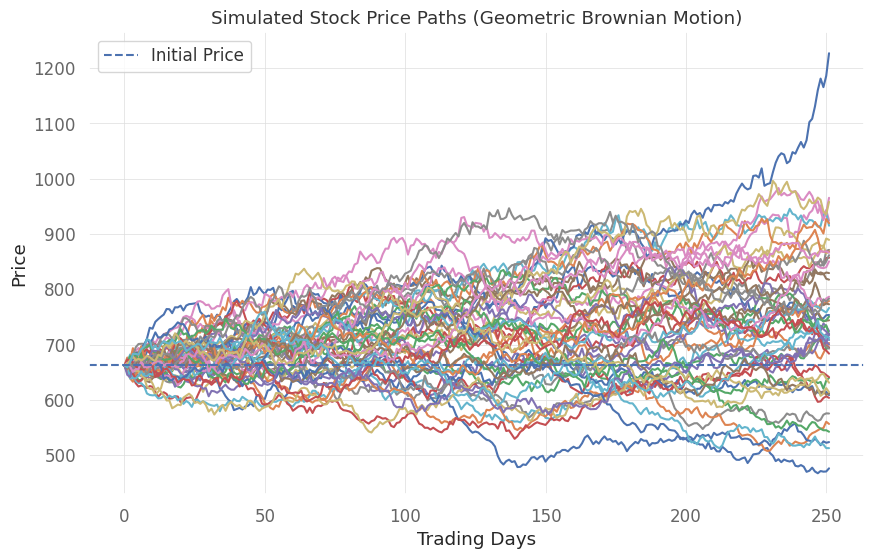

In [76]:
S0 = float(data["Close"].iloc[-1])
mu = data["log_returns"].mean()*252
sigma = data["log_returns"].std()*np.sqrt(252)

T = 1
dt = 1/252
N = int(T/dt)
paths = 1000

S_P = np.zeros((N, paths))
S_P[0] = S0

for t in range(1, N):
    z = np.random.standard_normal(paths)
    S_P[t] = S_P[t-1] * np.exp((mu - 0.5*sigma**2)*dt + sigma*np.sqrt(dt)*z)



plt.figure(figsize=(10,6))

plt.plot(S_P[:, :50])  # plot first 50 paths to avoid clutter

plt.title("Simulated Stock Price Paths (Geometric Brownian Motion)")
plt.xlabel("Trading Days")
plt.ylabel("Price")

plt.axhline(S0, linestyle="--", label="Initial Price")

plt.legend()

plt.show()

The plot is showing 50 of the 1000 simulations

#Martingale Property Under Risk Neutral Measure

In [77]:
path_grid = [100, 500, 1000, 5000, 10000, 20000]

results = []

for p in path_grid:

    S_Q = np.zeros((N, p))
    S_Q[0] = S0

    for t in range(1, N):
        z = np.random.standard_normal(p)
        S_Q[t] = S_Q[t-1] * np.exp((r - 0.5*sigma**2)*dt + sigma*np.sqrt(dt)*z)

    discounted = np.exp(-r*T) * S_Q[-1]

    results.append(discounted.mean())

for p, val in zip(path_grid, results):
    print(f"Paths: {p:6d} | Mean discounted price: {val:.2f}")

print("Initial price:", S0)

Paths:    100 | Mean discounted price: 661.49
Paths:    500 | Mean discounted price: 662.05
Paths:   1000 | Mean discounted price: 656.34
Paths:   5000 | Mean discounted price: 660.03
Paths:  10000 | Mean discounted price: 662.89
Paths:  20000 | Mean discounted price: 662.32
Initial price: 662.2899780273438


Increasing the number of paths shows convergence towards the actual initial price.

#Black-scholes option pricing

In [78]:
from scipy.stats import norm

def black_scholes_call(S0, K, T, r, sigma):

    d1 = (np.log(S0 / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)

    call = S0 * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2)

    return call

K = S0
T = 1

bs_price = black_scholes_call(S0, K, T, r, sigma)

print("Black–Scholes Call Price:", bs_price)

Black–Scholes Call Price: 55.1602476026593


#Monte carlo option pricing

Paths:    100 | MC Price: 50.6082
Paths:    200 | MC Price: 52.3855
Paths:    500 | MC Price: 52.9552
Paths:    750 | MC Price: 58.3833
Paths:   1000 | MC Price: 52.3781
Paths:   2500 | MC Price: 52.9790
Paths:   5000 | MC Price: 53.8755
Paths:   7500 | MC Price: 55.9135
Paths:  10000 | MC Price: 56.6285
Paths:  15000 | MC Price: 55.4952
Paths:  20000 | MC Price: 54.1366
Paths:  30000 | MC Price: 55.2047
Paths:  50000 | MC Price: 55.2615
Black–Scholes Price: 55.1602476026593


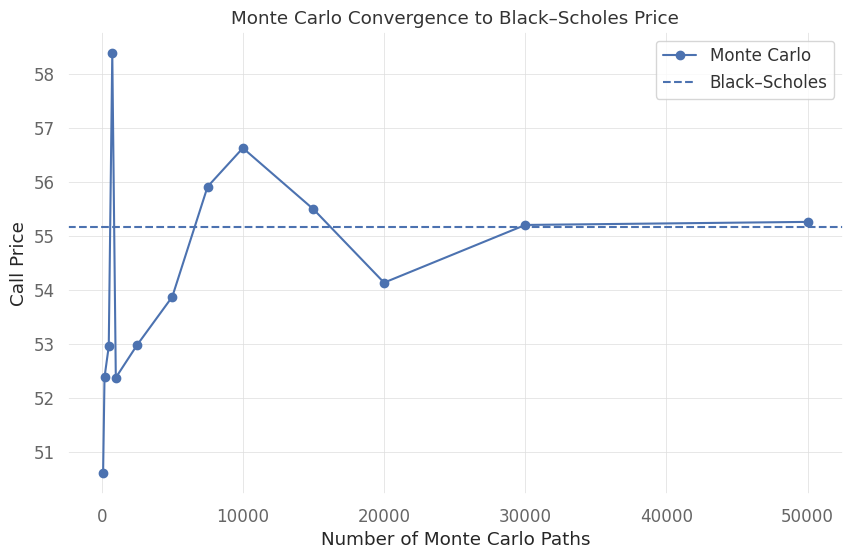

In [79]:
K = S0

path_grid = [100, 200, 500, 750, 1000, 2500, 5000, 7500, 10000, 15000, 20000, 30000, 50000]

mc_prices = []

for p in path_grid:

    S_Q = np.zeros((N, p))
    S_Q[0] = S0

    for t in range(1, N):
        z = np.random.standard_normal(p)
        S_Q[t] = S_Q[t-1] * np.exp((r - 0.5*sigma**2)*dt + sigma*np.sqrt(dt)*z)

    payoffs = np.maximum(S_Q[-1] - K, 0)
    price_mc = np.exp(-r*T) * payoffs.mean()

    mc_prices.append(price_mc)

for p, price in zip(path_grid, mc_prices):
    print(f"Paths: {p:6d} | MC Price: {price:.4f}")

print("Black–Scholes Price:", bs_price)


import matplotlib.pyplot as plt

plt.plot(path_grid, mc_prices, marker='o', label="Monte Carlo")
plt.axhline(bs_price, linestyle='--', label="Black–Scholes")

plt.xlabel("Number of Monte Carlo Paths")
plt.ylabel("Call Price")
plt.title("Monte Carlo Convergence to Black–Scholes Price")
plt.legend()
plt.show()

Clearly the monte carlo option pricing is converging towards the black scholes price of the option.

#Merton jump diffusion model

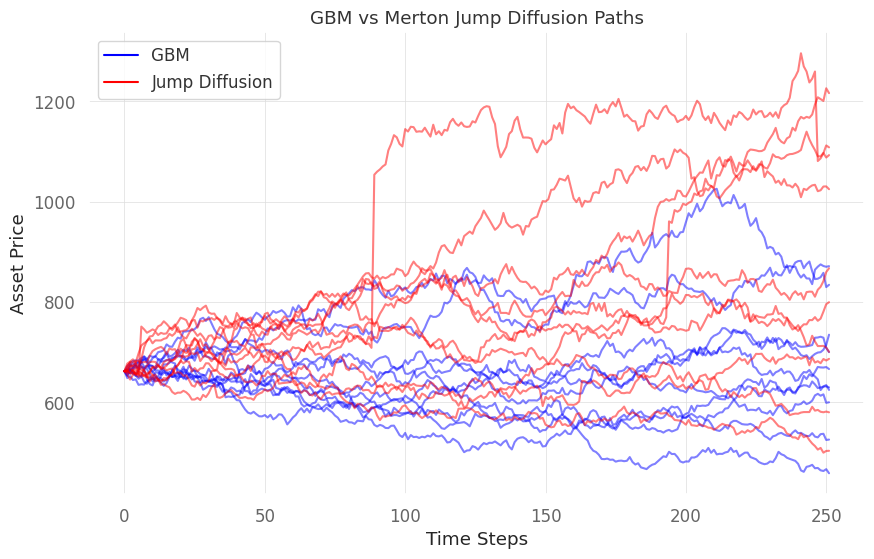

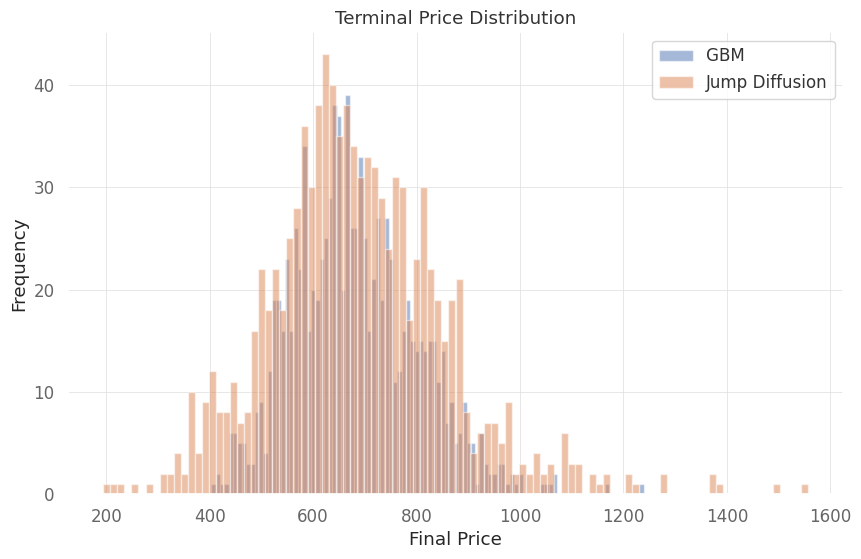

In [80]:

lambda_jump = 0.75
mu_jump = -0.1
sigma_jump = 0.2

k = np.exp(mu_jump + 0.5 * sigma_jump**2) - 1

S_GBM = np.zeros((N, paths))
S_GBM[0] = S0

for t in range(1, N):
    z = np.random.normal(size=paths)
    S_GBM[t] = S_GBM[t-1] * np.exp((r - 0.5 * sigma**2) * dt + sigma * np.sqrt(dt) * z)


S_MJD = np.zeros((N, paths))
S_MJD[0] = S0

for t in range(1, N):

    z = np.random.normal(size=paths)

    jumps = np.random.poisson(lambda_jump * dt, paths)

    jump_sizes = np.exp(mu_jump + sigma_jump * np.random.normal(size=paths))

    S_MJD[t] = S_MJD[t-1] * np.exp((r - lambda_jump * k - 0.5 * sigma**2) * dt
                                  + sigma * np.sqrt(dt) * z) * (jump_sizes ** jumps)

import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

for i in range(10):
    plt.plot(S_GBM[:, i], color="blue", alpha=0.5)

for i in range(10):
    plt.plot(S_MJD[:, i], color="red", alpha=0.5)

plt.title("GBM vs Merton Jump Diffusion Paths")
plt.xlabel("Time Steps")
plt.ylabel("Asset Price")

plt.plot([], [], color="blue", label="GBM")
plt.plot([], [], color="red", label="Jump Diffusion")

plt.legend()
plt.show()

plt.figure(figsize=(10,6))

plt.hist(S_GBM[-1], bins=100, alpha=0.5, label="GBM")
plt.hist(S_MJD[-1], bins=100, alpha=0.5, label="Jump Diffusion")

plt.title("Terminal Price Distribution")
plt.xlabel("Final Price")
plt.ylabel("Frequency")

plt.legend()
plt.show()

The Merton jump diffusion model extends the standard geometric Brownian motion by allowing the asset price to experience sudden jumps in addition to continuous diffusion. This captures extreme market movements such as crashes or large price changes that cannot be explained by the GBM model alone. By comparing simulated paths and terminal price distributions, we observe that the jump diffusion model produces more abrupt movements and heavier tails than GBM. This highlights how incorporating jumps can produce more realistic asset price dynamics and better capture the risk of extreme events in financial markets.

#Volatility with GARCH

Iteration:      1,   Func. Count:      6,   Neg. LLF: 33229048816.034725
Iteration:      2,   Func. Count:     15,   Neg. LLF: 2287651729.464292
Iteration:      3,   Func. Count:     22,   Neg. LLF: 7167.750418938253
Iteration:      4,   Func. Count:     28,   Neg. LLF: 6458.233823717568
Iteration:      5,   Func. Count:     35,   Neg. LLF: 5425.853377062134
Iteration:      6,   Func. Count:     41,   Neg. LLF: 5224.342023976307
Iteration:      7,   Func. Count:     46,   Neg. LLF: 5223.969079263588
Iteration:      8,   Func. Count:     51,   Neg. LLF: 5223.71811415104
Iteration:      9,   Func. Count:     56,   Neg. LLF: 5223.711153358068
Iteration:     10,   Func. Count:     61,   Neg. LLF: 5223.7110775280025
Iteration:     11,   Func. Count:     66,   Neg. LLF: 5223.711070637747
Iteration:     12,   Func. Count:     70,   Neg. LLF: 5223.711070637464
Optimization terminated successfully    (Exit mode 0)
            Current function value: 5223.711070637747
            Iterations: 12


Text(0.5, 1.0, 'Conditional Volatility (GARCH)')

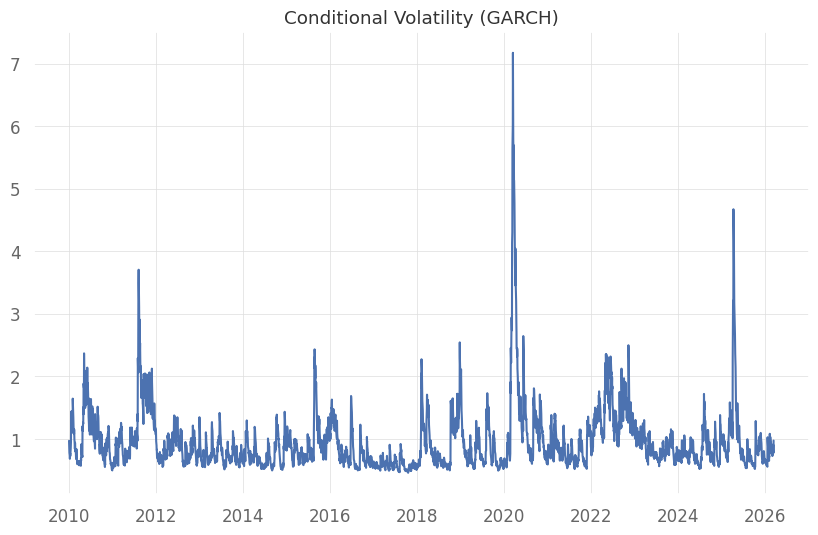

In [81]:
returns = data["log_returns"]*100

model = arch_model(returns, vol='Garch', p=1, q=1)

res = model.fit()

print(res.summary())


vol = res.conditional_volatility

plt.plot(vol)
plt.title("Conditional Volatility (GARCH)")

Earlier we saw the volatility clustering and the fat tails of the financial data. Now we can apply the GARCH(1,1) to model the time-varying volatility structure. Both the alpha and beta terms are clearly significant. The high beta shows that past volatility influences current volatility. The plot clearly shows volatility clustering, see for example 2020 (Covid-19)

#simple trading strategy with backtest

Sharpe: -0.23129323246379918


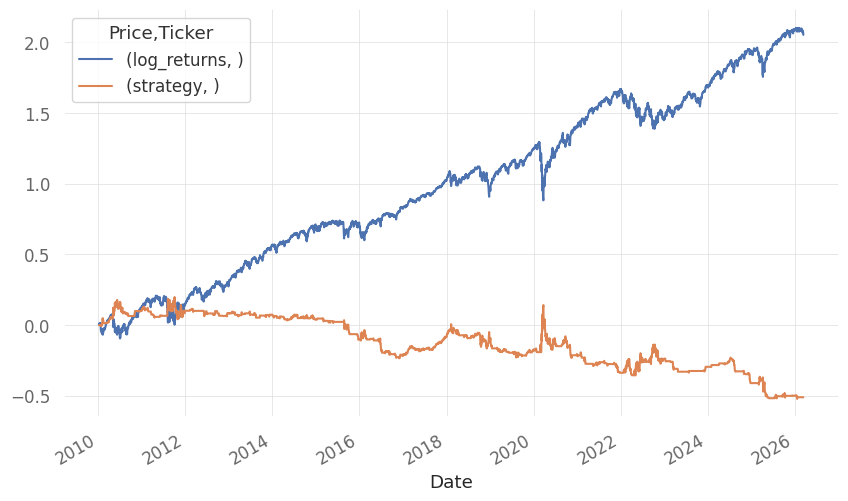

In [82]:
data["vol"] = vol

threshold_high = data["vol"].quantile(0.8)
threshold_low = data["vol"].quantile(0.2)

data["signal"] = 0
data.loc[data["vol"] > threshold_high, "signal"] = -1
data.loc[data["vol"] < threshold_low, "signal"] = 1

data["strategy"] = data["signal"].shift(1) * data["log_returns"]

data[["log_returns","strategy"]].cumsum().plot()

sharpe = np.sqrt(252) * data["strategy"].mean() / data["strategy"].std()

print("Sharpe:", sharpe)

Clearly this strategy is not good for this stock, we are losing money. Let's look at a different approach.

#volatility‑managed trend‑following strategy

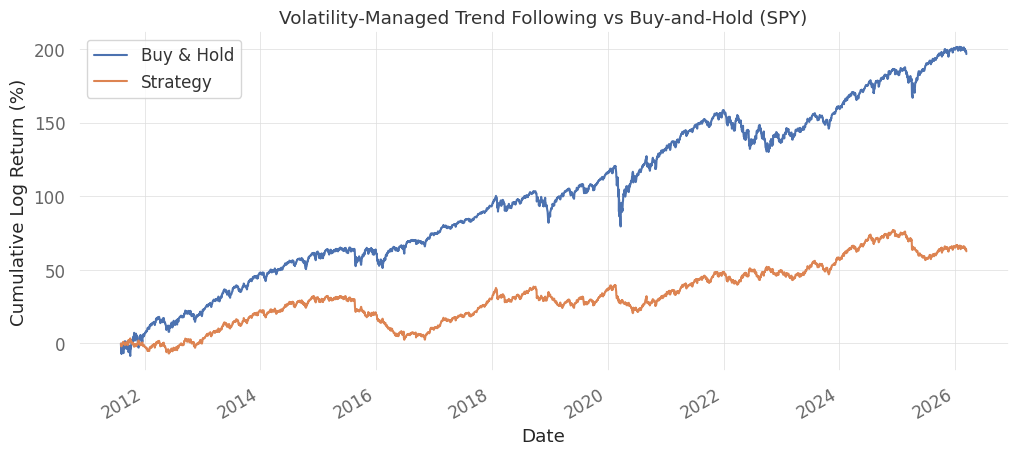

Sharpe ratio: 0.43
             Close_SPY  trend_signal  position  strategy
Date                                                    
2026-03-09  678.270020             1  0.690980  0.007179
2026-03-10  677.179993             1  0.701049 -0.001111
2026-03-11  676.330017             1  0.754745 -0.000880
2026-03-12  666.059998             1  0.809861 -0.011549
2026-03-13  662.289978             1  0.646047 -0.004597


In [84]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# -------------------------------
# Flatten MultiIndex columns if present
# -------------------------------
if isinstance(data.columns, pd.MultiIndex):
    data.columns = [col[0] if col[1] == '' else f"{col[0]}_{col[1]}" for col in data.columns]


fast_window = 50
slow_window = 200
target_vol = 10
max_leverage = 2


data['fast_ma'] = data['Close_SPY'].rolling(fast_window).mean()
data['slow_ma'] = data['Close_SPY'].rolling(slow_window).mean()


data['trend_signal'] = 0
data.loc[data['fast_ma'] > data['slow_ma'], 'trend_signal'] = 1
data.loc[data['fast_ma'] < data['slow_ma'], 'trend_signal'] = -1


data = data.dropna(subset=['fast_ma', 'slow_ma', 'vol', 'log_returns'])


data['position'] = data['trend_signal'] * target_vol / (data['vol'] * np.sqrt(252))

data['position'] = data['position'].clip(-max_leverage, max_leverage)


data['strategy'] = data['position'].shift(1) * data['log_returns']

data = data.dropna(subset=['strategy'])


data[['log_returns', 'strategy']].cumsum().multiply(100).plot(figsize=(12,5))
plt.title('Volatility-Managed Trend Following vs Buy-and-Hold (SPY)')
plt.ylabel('Cumulative Log Return (%)')
plt.legend(['Buy & Hold', 'Strategy'])
plt.show()

sharpe = np.sqrt(252) * data['strategy'].mean() / data['strategy'].std()
print(f'Sharpe ratio: {sharpe:.2f}')

print(data[['Close_SPY','trend_signal','position','strategy']].tail())

This strategy give us a positive sharpe ratio, looking at the plot it gives us a positive return. It can be interesting to see what happens when we apply this strat to a stock that is decreasing over time.

/usr/local/lib/python3.12/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
/tmp/ipykernel_703/2735594504.py:12: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-ver

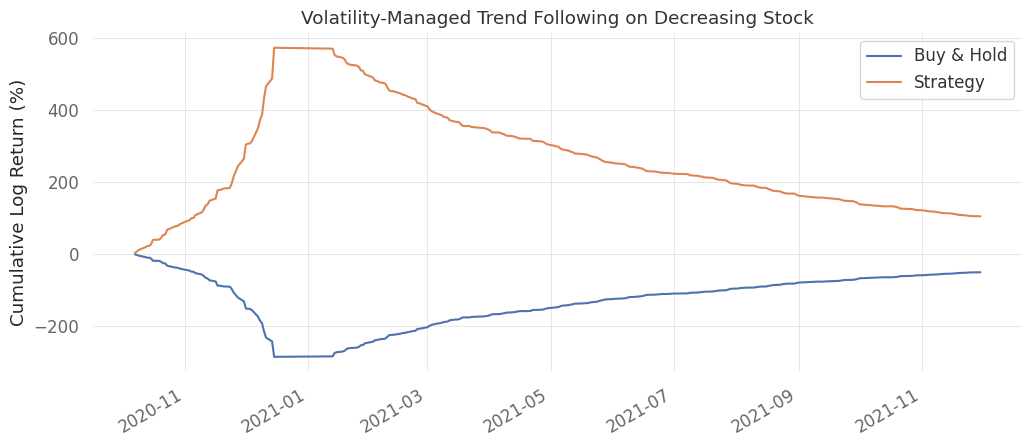

Sharpe ratio: 0.70
            Close_SPY  trend_signal  position  strategy
2021-11-24 -97.752875            -1      -2.0 -0.013036
2021-11-25 -97.839614            -1      -2.0 -0.001774
2021-11-26 -98.180551            -1      -2.0 -0.006957
2021-11-29 -98.199018            -1      -2.0 -0.000376
2021-11-30 -98.471469            -1      -2.0 -0.005541


In [88]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


dates = pd.date_range(start='2020-01-01', periods=500, freq='B')
price = 100 - np.cumsum(np.abs(np.random.normal(0.1, 0.5, size=len(dates))))

data = pd.DataFrame({'Close_SPY': price}, index=dates)

data['log_returns'] = np.log(data['Close_SPY'] / data['Close_SPY'].shift(1))
data['log_returns'].iloc[0] = 0

data['vol'] = data['log_returns'].rolling(20).std()
data['vol'].iloc[:20] = data['vol'].iloc[20]


fast_window = 50
slow_window = 200
target_vol = 10
max_leverage = 2


data['fast_ma'] = data['Close_SPY'].rolling(fast_window).mean()
data['slow_ma'] = data['Close_SPY'].rolling(slow_window).mean()


data['trend_signal'] = 0
data.loc[data['fast_ma'] > data['slow_ma'], 'trend_signal'] = 1
data.loc[data['fast_ma'] < data['slow_ma'], 'trend_signal'] = -1


data = data.dropna(subset=['fast_ma','slow_ma','vol','log_returns'])


data['position'] = data['trend_signal'] * target_vol / (data['vol'] * np.sqrt(252))
data['position'] = data['position'].clip(-max_leverage, max_leverage)

data['strategy'] = data['position'].shift(1) * data['log_returns']
data = data.dropna(subset=['strategy'])


data[['log_returns','strategy']].cumsum().multiply(100).plot(figsize=(12,5))
plt.title('Volatility-Managed Trend Following on Decreasing Stock')
plt.ylabel('Cumulative Log Return (%)')
plt.legend(['Buy & Hold','Strategy'])
plt.show()


sharpe = np.sqrt(252) * data['strategy'].mean() / data['strategy'].std()
print(f'Sharpe ratio: {sharpe:.2f}')

print(data[['Close_SPY','trend_signal','position','strategy']].tail())

This strategy can work, but we are not sure over time. A stock that has a shock at first and increases slowly will for a long time have a negative longterm moving average and a positive shortterm moving average.